In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import math
import datetime

import tensorflow as tf
import warnings
warnings.filterwarnings(action="ignore")

📋Load the dataset

In [ ]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

In [ ]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [ ]:
train.shape

(42000, 785)

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


In [ ]:
test.shape

(28000, 784)

In [ ]:
X=train.iloc[:,1:785]
y=train.iloc[:,0]

X_test=test.iloc[:,0:784]

📋Splitting dataset into training and testing


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=1729)

In [ ]:
print("X_train: ",X_train.shape)
print("X_validation: ",X_val.shape)
print("y_train: ",y_train.shape)
print("y_validation: ",y_val.shape)

X_train:  (33600, 784)
X_validation:  (8400, 784)
y_train:  (33600,)
y_validation:  (8400,)


📋Converting training, testing, and validation data into array

In [ ]:
x_train_re=X_train.to_numpy().reshape(33600,28,28)
y_train_re=y_train.values
x_validation_re=X_val.to_numpy().reshape(8400,28,28)
y_validation_re=y_val.values
x_test_re=test.to_numpy().reshape(28000,28,28)

In [ ]:
print("x_train:",x_train_re.shape)
print("y_train:",y_train_re.shape)
print("x_validation:",x_validation_re.shape)
print("y_validation:",y_validation_re.shape)
print("x_test:",x_test_re.shape)

x_train: (33600, 28, 28)
y_train: (33600,)
x_validation: (8400, 28, 28)
y_validation: (8400,)
x_test: (28000, 28, 28)


In [ ]:
(_,Image_width,Image_height)=x_train_re.shape
Image_channels=1

print("Image_width:",Image_width)
print("Image_height:",Image_height)
print("Image_channels:",Image_channels)

Image_width: 28
Image_height: 28
Image_channels: 1


📋 Visualization

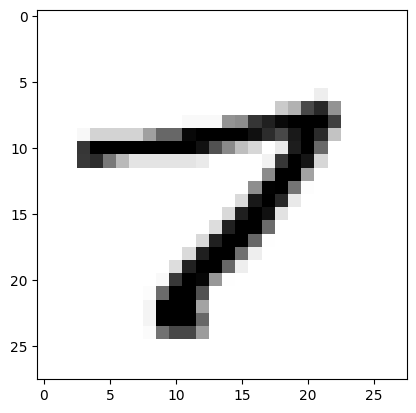

In [ ]:
plt.imshow(x_train_re[10],cmap=plt.cm.binary)
plt.show()

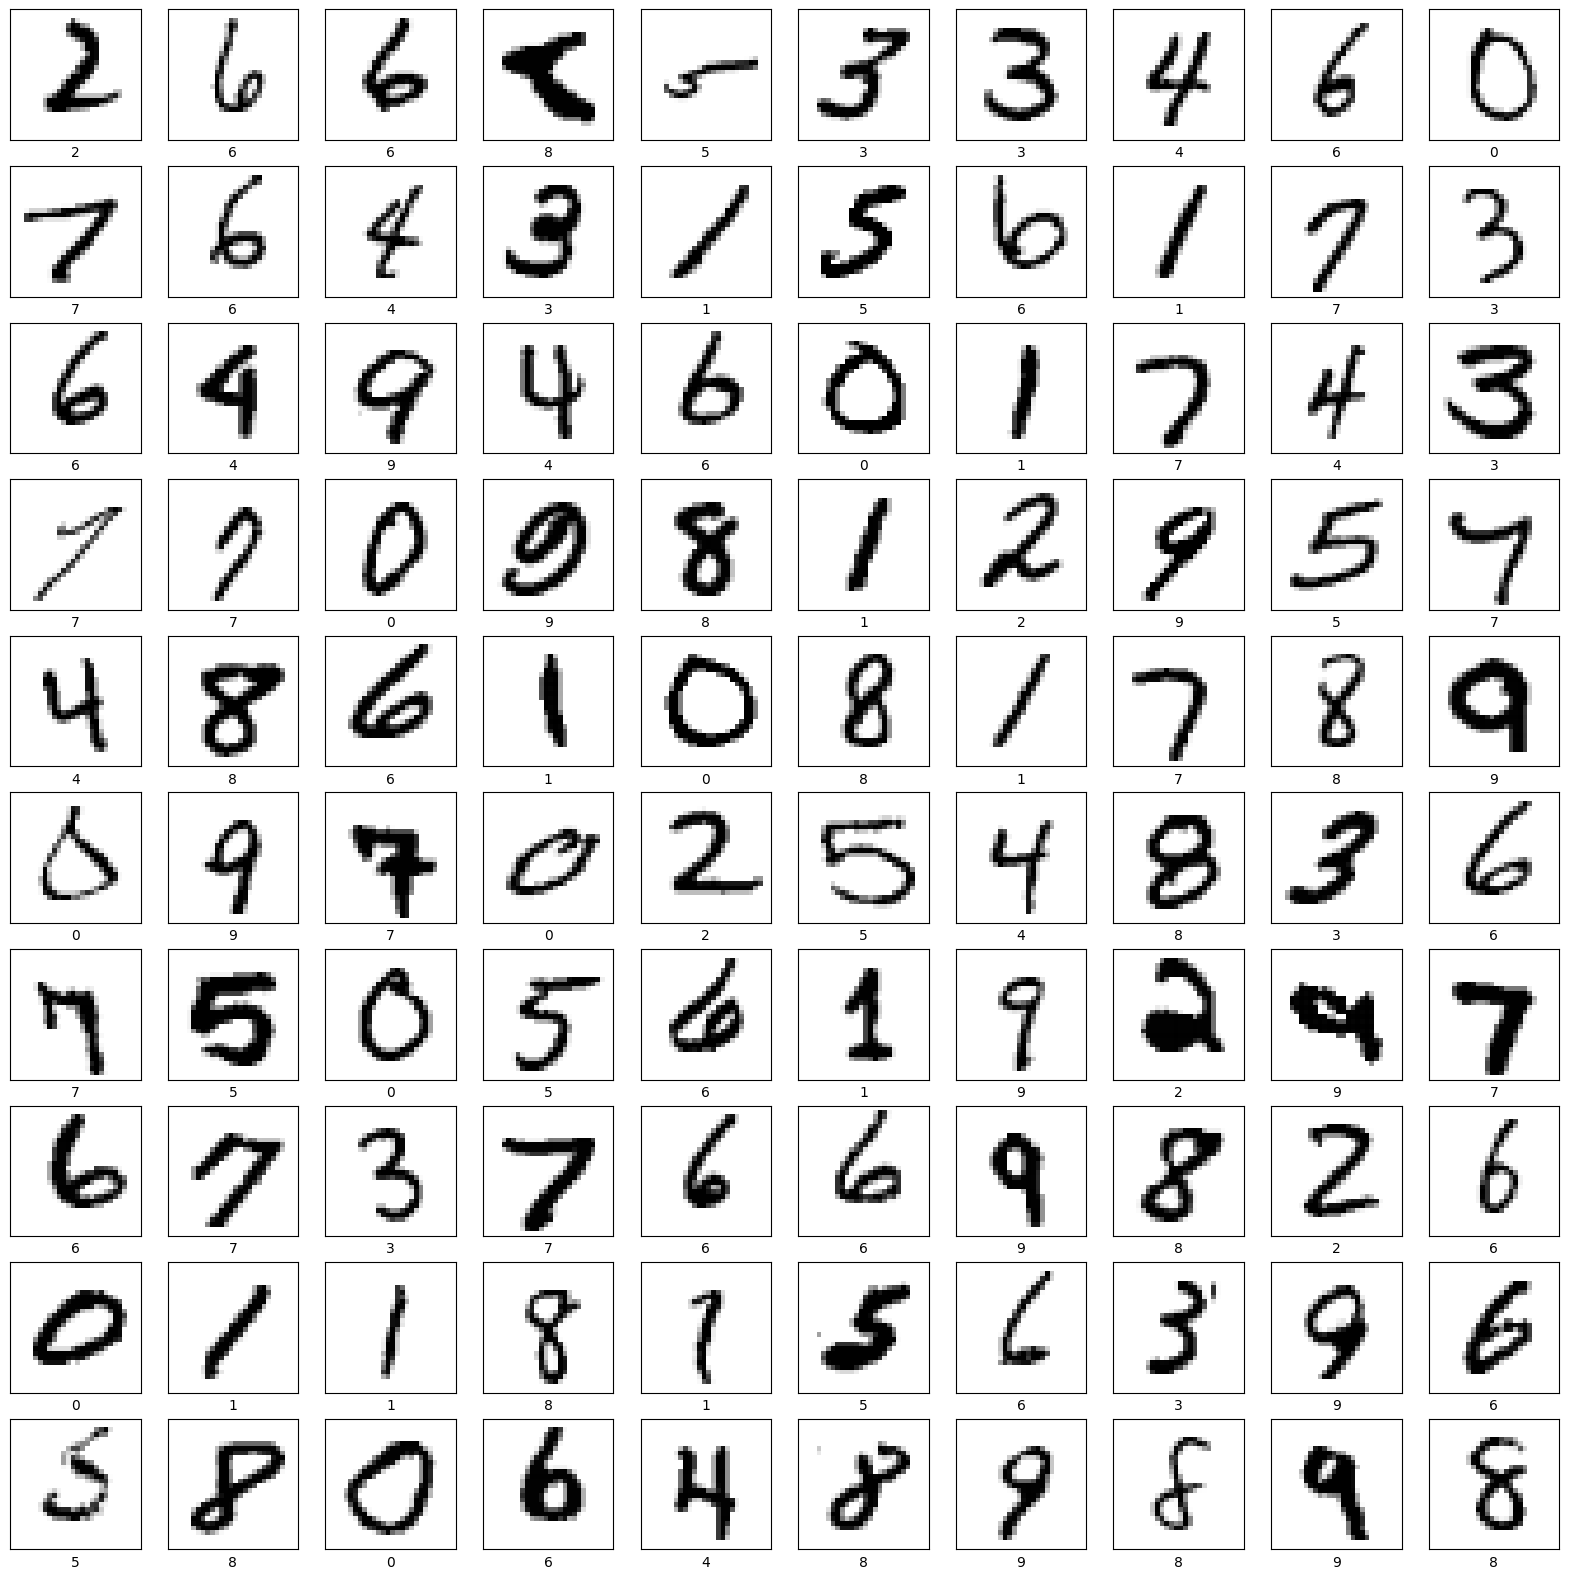

In [ ]:
numbers_to_display=100
num_cells=math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(20,20))
for i in range(numbers_to_display):
  plt.subplot(num_cells,num_cells,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train_re[i],cmap=plt.cm.binary)
  plt.xlabel(y_train_re[i])
plt.show()

📋 Reshaping train,test, and validation data

In [ ]:
x_train_with_chanels=x_train_re.reshape(x_train_re.shape[0],Image_width,Image_height,Image_channels)
x_validation_with_chanels=x_validation_re.reshape(x_validation_re.shape[0],Image_width,Image_height,Image_channels)
x_test_with_chanels=x_test_re.reshape(x_test_re.shape[0],Image_width,Image_height,Image_channels)

In [ ]:
print("x_train_with_chanels:",x_train_with_chanels.shape)
print("x_validation_with_chanels:",x_validation_with_chanels.shape)
print("x_test_with_chanels:",x_test_with_chanels.shape)

x_train_with_chanels: (33600, 28, 28, 1)
x_validation_with_chanels: (8400, 28, 28, 1)
x_test_with_chanels: (28000, 28, 28, 1)


📋 Normalize train, test, and validation dataset

In [ ]:
x_train_normalized=x_train_with_chanels/255
x_validation_normalized=x_validation_with_chanels/255
x_test_normalized=x_test_with_chanels/255

📋 Model - CNN

In [ ]:
from keras.models import Sequential
from keras.layers import Convolution2D,MaxPooling2D,Dense,Dropout,Flatten
from keras.activations import softmax,relu
from keras.initializers import VarianceScaling

In [ ]:
model=Sequential()

model.add(Convolution2D(input_shape=(Image_width,Image_height,Image_channels),
                        kernel_size=5,
                        filters=8,
                        strides=1,
                        activation=relu,
                        kernel_initializer=VarianceScaling()))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Convolution2D(kernel_size=5,filters=16,strides=1,activation=relu,
                        kernel_initializer=VarianceScaling()))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Flatten())

model.add(Dense(units=128,activation=relu))
model.add(Dropout(0.2))

model.add(tf.keras.layers.Dense(
    units=10,
    activation=softmax,
    kernel_initializer=VarianceScaling()
))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,610 (146.91 KB)

 Trainable params: 37,610 (146.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.optimizers import Adam
from keras.losses import sparse_categorical_crossentropy

model.compile(optimizer=Adam(),loss=sparse_categorical_crossentropy,metrics=["accuracy"])

📋 Train the model

In [ ]:
training_history=model.fit(
    x_train_normalized,
    y_train_re,
    epochs=15,
    validation_data=(x_validation_normalized,y_validation_re))
print("The model has successfully trained")


Epoch 1/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.8274 - loss: 0.5529 - val_accuracy: 0.9760 - val_loss: 0.0806
Epoch 2/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.9716 - loss: 0.0888 - val_accuracy: 0.9808 - val_loss: 0.0634
Epoch 3/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9803 - loss: 0.0647 - val_accuracy: 0.9814 - val_loss: 0.0563
Epoch 4/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9840 - loss: 0.0489 - val_accuracy: 0.9846 - val_loss: 0.0471
Epoch 5/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9875 - loss: 0.0389 - val_accuracy: 0.9842 - val_loss: 0.0509
Epoch 6/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9880 - loss: 0.0317 - val_accuracy: 0.9869 - val_loss: 0.0447
Epoch 7/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9916 - loss: 0.0248 - val_accuracy: 0.9880 - val_loss: 0.0406
Epoch 8/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9936 -

📋 Model Evaluation

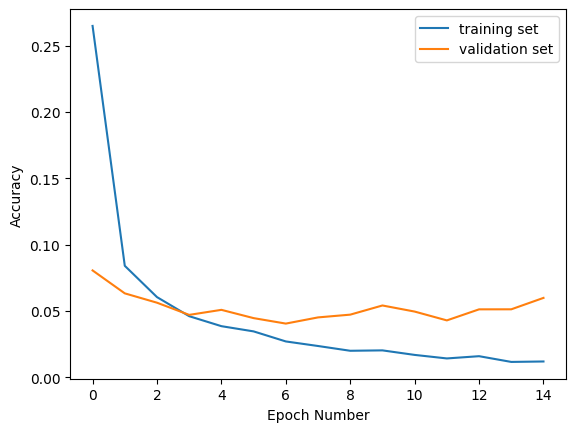

In [ ]:
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.plot(training_history.history["loss"],label="training set")
plt.plot(training_history.history["val_loss"],label="validation set")
plt.legend()

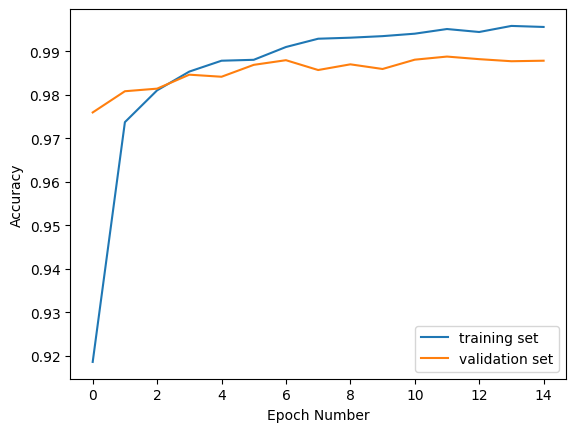

In [ ]:
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.plot(training_history.history["accuracy"],label="training set")
plt.plot(training_history.history["val_accuracy"],label="validation set")
plt.legend()

📋 Testing model on train and test dataset

In [ ]:
train_loss,train_accuracy=model.evaluate(x_train_normalized,y_train_re)

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9972 - loss: 0.0087


In [ ]:
print("Train loss:",round(train_loss,2)*100,"%")
print("Train accuracy:",round(train_accuracy,2)*100,"%")

Train loss: 1.0 %
Train accuracy: 100.0 %


📋 Save the model

In [ ]:
model_name="digits_recognition_cnn.h5"
model.save(model_name,save_format="h5")

In [ ]:
loaded_model=tf.keras.models.load_model(model_name)

In [ ]:
predictions_one_hot=loaded_model.predict([x_validation_normalized])

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
print("prediction_one_hot:",predictions_one_hot.shape)

prediction_one_hot: (8400, 10)


In [ ]:
predictions=np.argmax(predictions_one_hot,axis=1)
pd.DataFrame(predictions,columns=["digit"]).head()

,digit
0,1
1,9
2,0
3,6
4,7


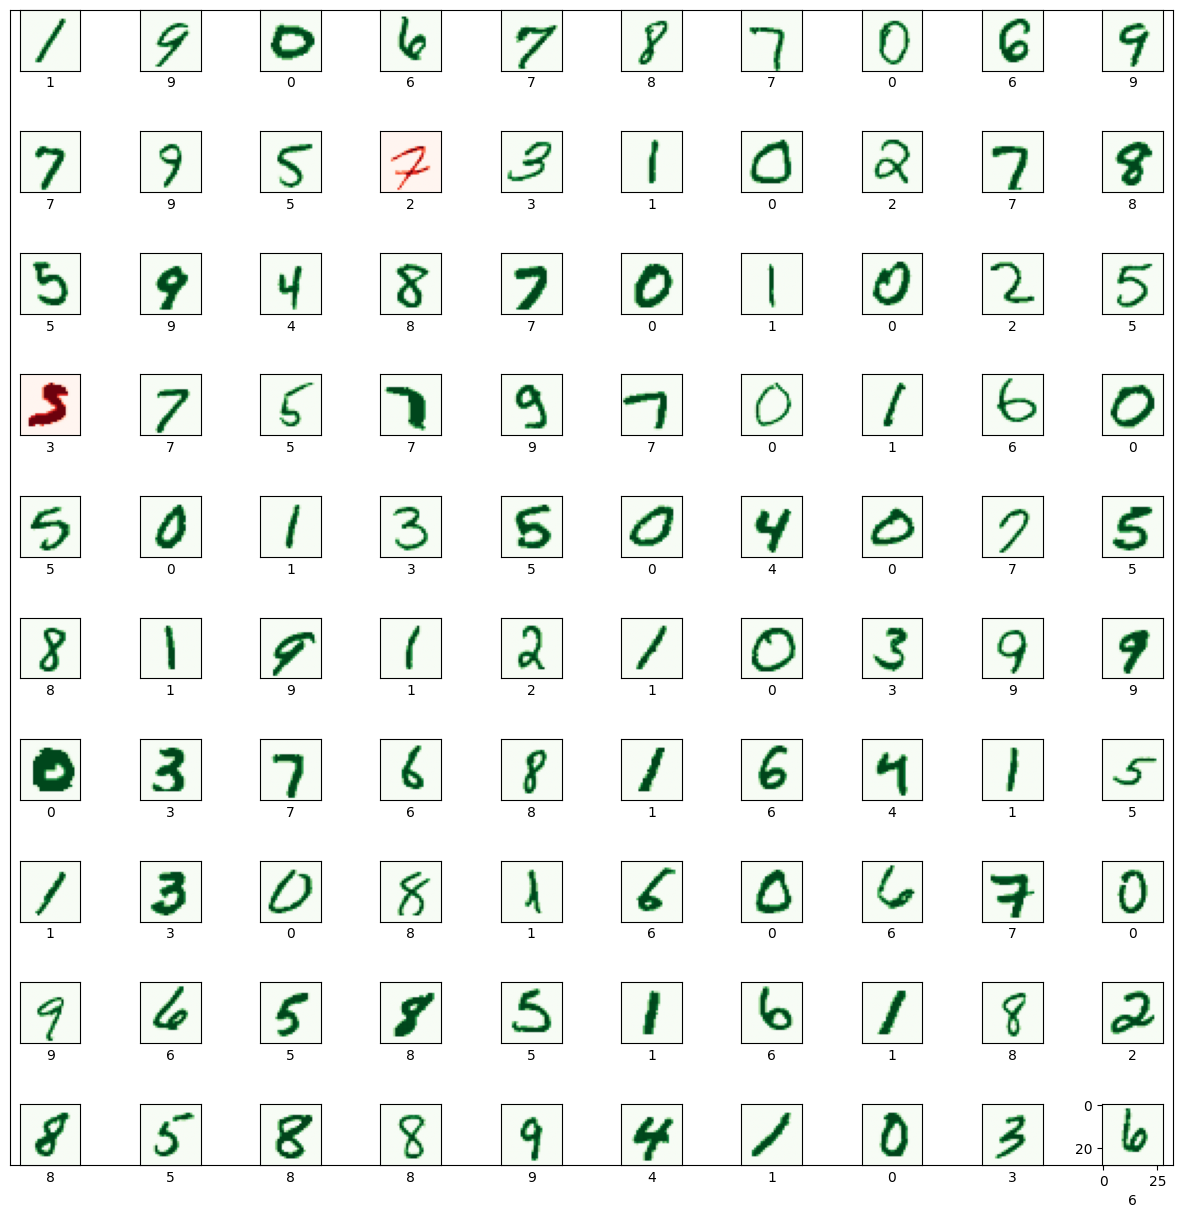

In [ ]:
numbers_to_display=225
num_cels=math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(15,15))

for plot_index in range(numbers_to_display):
  predicted_label=predictions[plot_index]
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  color_map= "Greens" if predicted_label==y_validation_re[plot_index] else "Reds"
  plt.subplot(num_cells,num_cells,plot_index+1)
  plt.imshow(x_validation_normalized[plot_index].reshape((Image_width,Image_height)),cmap=color_map)
  plt.xlabel(predicted_label)
plt.subplots_adjust(hspace=1,wspace=0.5)
plt.show()